# Detección de Cáncer de Piel con Redes Neuronales Convolucionales

En este proyecto, desarrollamos un modelo de aprendizaje profundo utilizando Keras para la detección de cáncer de piel. Utilizamos el dataset "Skin Cancer MNIST: HAM10000", que contiene imágenes de diferentes tipos de lesiones cutáneas. El objetivo es clasificar estas imágenes en varias categorías de cáncer de piel.

# Inicio de proyecto

In [1]:
# import libraries
# for data manipulation
import pandas as pd
import numpy as np

# for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# DL Libraries
import tensorflow as tf
from tensorflow import keras
from keras.layers import Conv2D , MaxPooling2D ,Dropout , Flatten , Dense ,BatchNormalization ,Concatenate ,Input 
from keras.models import Sequential ,Model

# SK Learn library to split train and test data
from sklearn.model_selection import train_test_split

# other libraries
import cv2
import os
from PIL import Image
from tensorflow.keras.preprocessing.image import img_to_array, load_img

## Carga de datos

In [2]:
path_dir_option = ''

if path_dir_option == 'local':

    data_hmnist_path =os.path.join('archive', 'HAM10000_metadata.csv')

else:

    data_hmnist_path = os.path.join('/kaggle/input','skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

print(data_hmnist_path)

data_hmnist = pd.read_csv(data_hmnist_path)

data_hmnist.head()

/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


# Análisis de datos

Empezamos con un análisis exploratorio de los datos.

In [3]:
#add column with path to image

data_hmnist['path'] = data_hmnist['image_id'].apply(lambda x: os.path.join(data_hmnist_path, 'HAM10000_images', x + '.jpg'))
data_hmnist.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...


In [4]:
# checking for the null values
data_hmnist.isna().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
path             0
dtype: int64

In [5]:
# replacing the missing values of age with mean
data_hmnist['age'] = data_hmnist['age'].fillna(round(data_hmnist['age'].mean()))

data_hmnist.isna().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
path            0
dtype: int64

Una vez vistos los datos, podemos ver que hay 7 clases diferentes de cáncer de piel. Cada clase tiene un número diferente de imágenes.

## Análisis Estadístico

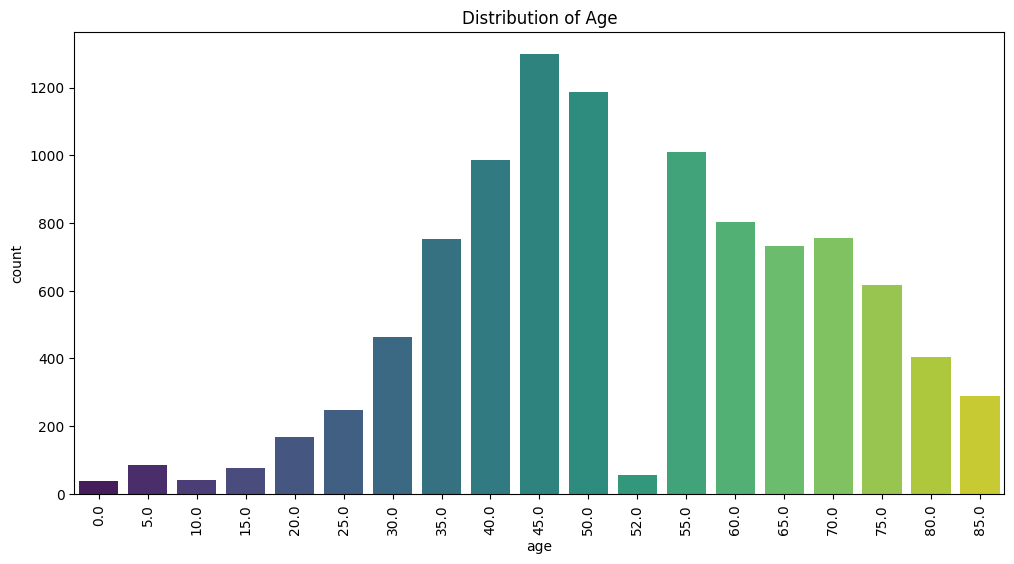

In [6]:
import seaborn as sns

import matplotlib.pyplot as plt

# distribution of ages
plt.figure(figsize=(12,6))

sns.countplot(data=data_hmnist ,x='age',palette='viridis')

plt.title('Distribution of Age')

plt.xticks(rotation=90)

plt.show()

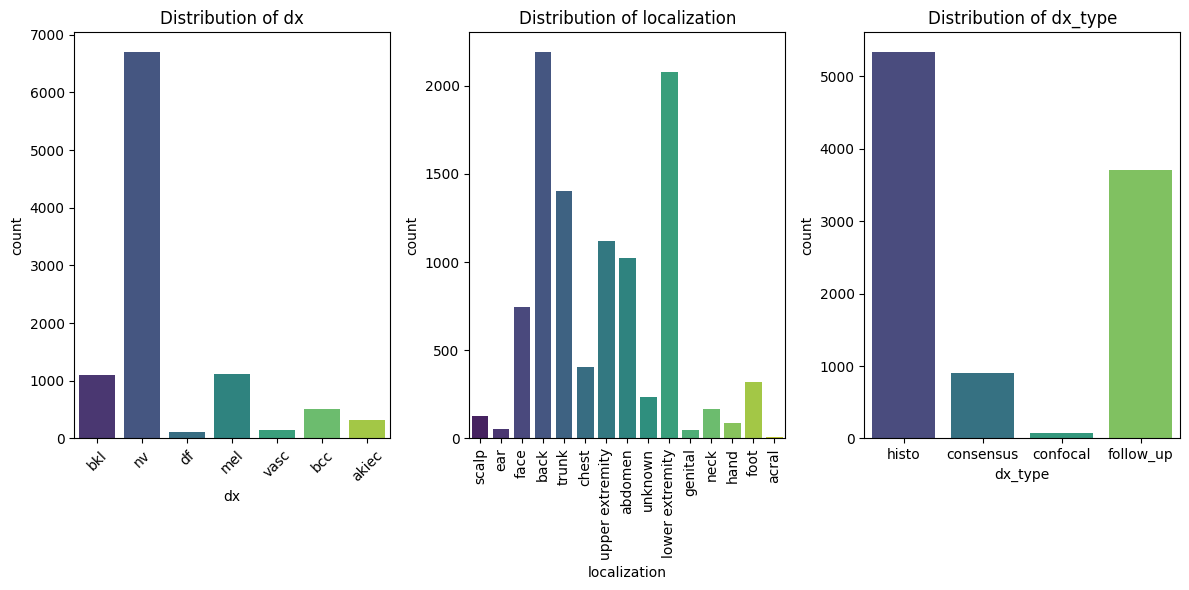

In [7]:
# distribution of other features

# dx, dx-type, localization
plt.figure(figsize=(12, 6))

plt.subplot(1,3,1)
sns.countplot(data=data_hmnist , x='dx' ,palette='viridis')
plt.title('Distribution of dx')
plt.xticks(rotation=45)

plt.subplot(1,3,2)
sns.countplot(data=data_hmnist,x='localization' ,palette='viridis')
plt.title('Distribution of localization')
plt.xticks(rotation=90)

plt.subplot(1,3,3)
sns.countplot(data=data_hmnist , x = 'dx_type' , palette='viridis')
plt.title('Distribution of dx_type')

plt.tight_layout()
plt.show()

In [8]:
# replacing unknown values in the sex column with male
# to prevent having extra column during label encoding

data_hmnist['sex'] = data_hmnist['sex'].replace('unknown', 'male')

data_hmnist['sex'].value_counts()

sex
male      5463
female    4552
Name: count, dtype: int64

In [9]:
# X_features include - age, dx_type, sex, localization

# y_feature - dx
metadata_features = data_hmnist[['age', 'dx_type', 'sex', 'localization']].copy()
metadata_features.head()

,age,dx_type,sex,localization
0,80.0,histo,male,scalp
1,80.0,histo,male,scalp
2,80.0,histo,male,scalp
3,80.0,histo,male,scalp
4,75.0,histo,male,ear


Se hace una conversion de datos categóricos con one hot encoding.

In [10]:
# changing categorical data into numerical data using dummies

metadata_features = pd.get_dummies(metadata_features, columns=['dx_type', 'sex', 'localization'], drop_first=True, dtype=int)
metadata_features.head()

,age,dx_type_consensus,dx_type_follow_up,dx_type_histo,sex_male,localization_acral,localization_back,localization_chest,localization_ear,localization_face,localization_foot,localization_genital,localization_hand,localization_lower extremity,localization_neck,localization_scalp,localization_trunk,localization_unknown,localization_upper extremity
0,80.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,80.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,80.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,80.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,75.0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [11]:
# normalizing the age value

metadata_features['age'] = metadata_features['age'] / metadata_features['age'].max()
metadata_features

,age,dx_type_consensus,dx_type_follow_up,dx_type_histo,sex_male,localization_acral,localization_back,localization_chest,localization_ear,localization_face,localization_foot,localization_genital,localization_hand,localization_lower extremity,localization_neck,localization_scalp,localization_trunk,localization_unknown,localization_upper extremity
0,0.941176,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0.941176,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,0.941176,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,0.941176,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,0.882353,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,0.470588,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10011,0.470588,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10012,0.470588,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10013,0.941176,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0


Convirtiendo las 7 etiquetas a 2 categorías:

- 'Melanocytic Nevi (nv)' - No Canceroso (0)
- 'Benign Keratosis-like Lesions (bkl)' - No Canceroso (0)
- 'Dermatofibroma (df)' - No Canceroso (0)
- 'Melanoma (mel)' - Canceroso (1)
- 'Vascular Lesions (vasc)' - No Canceroso (0)
- 'Basal Cell Carcinoma (bcc)' - Canceroso (1)
- 'Actinic Keratoses and Intraepithelial Carcinoma (akiec)' - Canceroso (1)


In [12]:
# Each type of 
label_mapping = {
    "nv": 0,
    "bkl": 1,
    "df": 2,
    "mel": 3,
    "vasc": 4,
    "bcc": 5,
    "akiec": 6
}

In [13]:
label_mapping2 = {
    "nv": 0,
    "bkl": 0,
    "df": 0,
    "mel": 1,
    "vasc": 0,
    "bcc": 1,
    "akiec": 1
}

## Carga de imágenes

In [14]:
# function to load_image data

def load_image(image_id  , image_folder):

    image_path = os.path.join(image_folder , f'{image_id}.jpg')

    return Image.open(image_path)

In [15]:
if path_dir_option == 'local':
    image_folder1 = os.path.join('archive', 'HAM10000_images_part_1')
    image_folder2 = os.path.join('archive', 'HAM10000_images_part_2')

else:
    image_folder1 = '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1'
    image_folder2 = '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2'


image_data = []
labels1 = []
labels2 = []


for idx,row in data_hmnist.iterrows():
    i_id = row['image_id']
    dx   = row['dx']
    
    try:
        image = load_image(i_id , image_folder1)

        
    except FileNotFoundError:
        image = load_image(i_id , image_folder2)

    image = image.resize((128,128))
    image = img_to_array(image) /255.0

    image_data.append(image)
    labels1.append(label_mapping[dx])
    labels2.append(label_mapping2[dx])

In [16]:
classes = ['Melanocytic Nevi (nv)',

           'Benign Keratosis-like Lesions (bkl)',

           'Dermatofibroma (df)',

           'Melanoma (mel)',

           'Vascular Lesions (vasc)',

           'Basal Cell Carcinoma (bcc)',

           'Actinic Keratoses and Intraepithelial Carcinoma (akiec)']

In [17]:
classes2 = ['Non Cancerous',

            'Cancerous']

Es hora de mostrar algunas imágenes del dataset. 

In [18]:
def show_samples(i_dex):
    plt.imshow(image_data[i_dex])
    plt.xlabel(f'{classes[labels1[i_dex]]} - {classes2[labels2[i_dex]]}')
    plt.show()

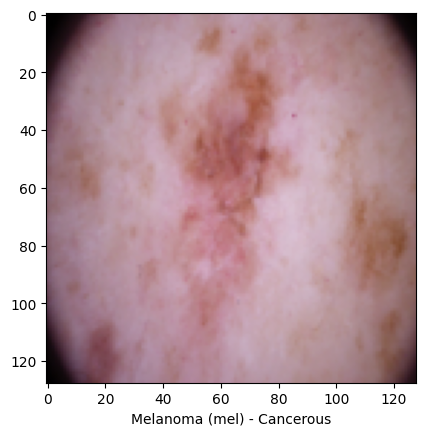

In [19]:
show_samples(1746)

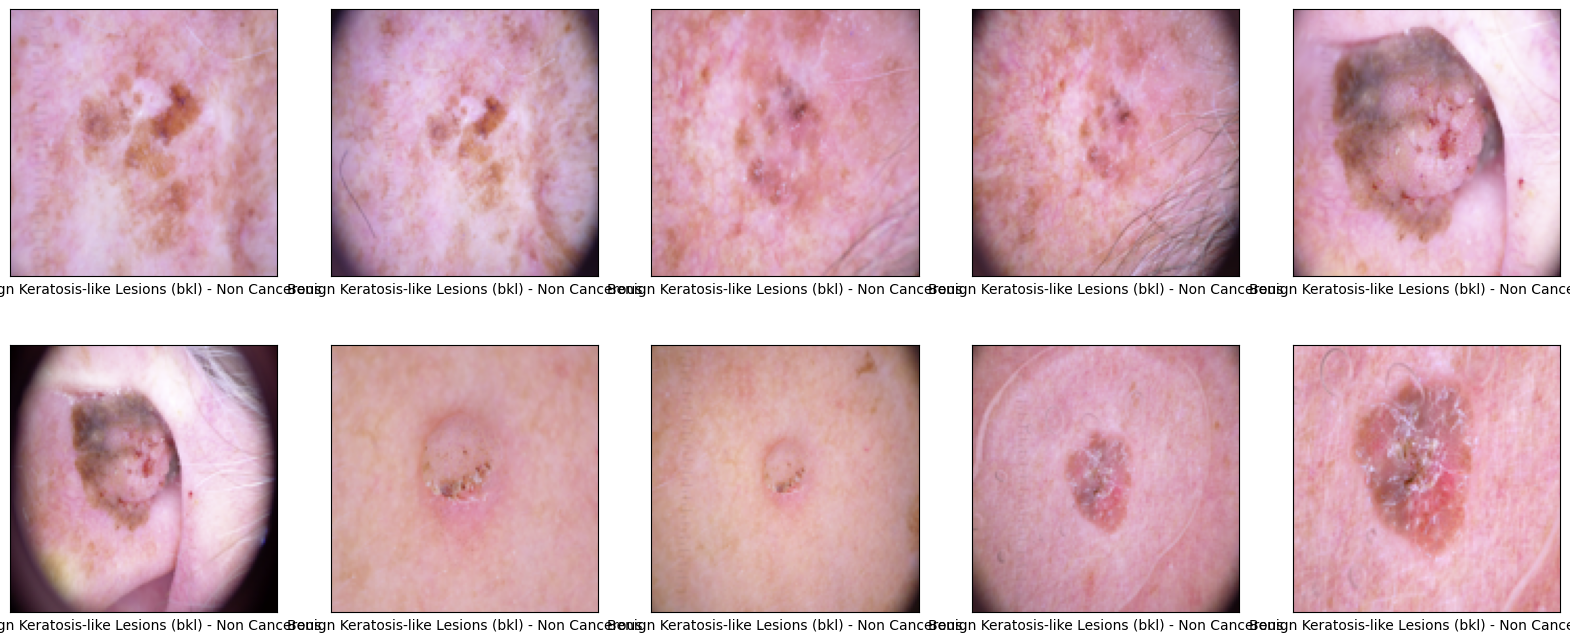

In [20]:
plt.figure(figsize=(20,8))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.xlabel(f'{classes[labels1[i]]} - {classes2[labels2[i]]}')
    plt.imshow(image_data[i])

Tenemos una cantidad de 10015 imágenes en total. 

In [21]:
print(len(image_data))
print(len(labels1))

10015
10015


## Aumento de datos
En este dataset se aplicará aumento de datos para aumentar la cantidad de imágenes y mejorar el rendimiento del modelo.

Primero definimos el generador de imágenes con el aumento de datos.
En este caso solo se aplicará aumento de datos a las imágenes de entrenamiento con rotaciones, y volteos horizontales y verticales.

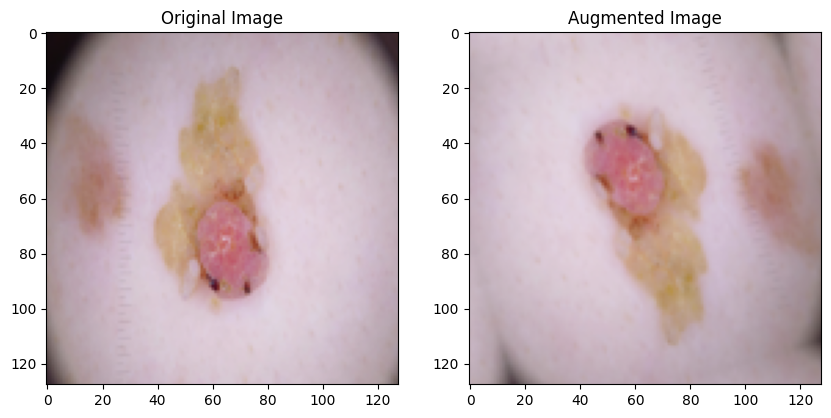

In [22]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.4),
])

result = data_augmentation(image_data[10])

plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image_data[10])

# Augmented image
plt.subplot(1, 2, 2)
plt.title("Augmented Image")
plt.imshow(result)

plt.show()

# Creación de datos de prueba y entrenamiento

Convertimos las labels en un array de numpy y les aplicamos un one hot encoding.

In [23]:
y = np.array(labels1)
from tensorflow.keras.utils import to_categorical
y_encoded = to_categorical(y,num_classes=7)
y_encoded[3]
y_encoded.shape

(10015, 7)

In [24]:
X_image = np.array(image_data)
X_image.shape

(10015, 128, 128, 3)

Segmentamos los datos en datos de entrenamiento y de prueba, con un ratio de 80% entrenamiento y 20% prueba.

In [25]:
X_train_image, X_test_image, y_encoded_train ,y_encoded_test = train_test_split(X_image, y_encoded ,test_size=.2 ,random_state=42)

Finalmente aplicamos el aumento de datos a las imágenes de entrenamiento.


In [26]:
#aumento de datos de datos prueba
print('Antes del aumento de datos')
print(X_train_image.shape)
print(y_encoded_train.shape)

X_train_augmented = []

y_encoded_train_augmented = []
#new data
for i in range(5000):
    modified_image =  data_augmentation(X_train_image[i])
    X_train_augmented.append(modified_image)
    y_encoded_train_augmented.append(y_encoded_train[i])

#rewrite the original 
for i in range(len(X_train_image)):
    X_train_augmented.append(X_train_image[i])
    y_encoded_train_augmented.append(y_encoded_train[i])
    

X_train_image =  np.array(X_train_augmented)
y_encoded_train = np.array(y_encoded_train_augmented)


print('Despues del aumento de datos')

print(X_train_image.shape)
print(y_encoded_train.shape)

Antes del aumento de datos
(8012, 128, 128, 3)
(8012, 7)
Despues del aumento de datos
(13012, 128, 128, 3)
(13012, 7)


Cantidad de datos de prueba y de entrenamiento

In [27]:
print(X_train_image.shape)
print(y_encoded_train.shape)

print(X_test_image.shape)
print(y_encoded_test.shape)

(13012, 128, 128, 3)
(13012, 7)
(2003, 128, 128, 3)
(2003, 7)


# Modelo de Red Neuronal Convolucional.

In [28]:
# creating a CNN + ANN model

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))
model.add(Dropout(0.5))
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(32, activation='relu'))

# o/p layer
model.add(Dense(7, activation='softmax'))

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compilación del modelo. 

In [29]:

from tensorflow.keras import metrics

# Model compilation with additional metrics
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall')
    ]
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,787,975 (56.41 MB)

 Trainable params: 14,787,975 (56.41 MB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento del modelo.

In [30]:
history = model.fit(X_train_image, y_encoded_train,
                    validation_data=(X_test_image, y_encoded_test),
                    batch_size=32,
                    validation_split=.2,
                    epochs=1)

407/407 ━━━━━━━━━━━━━━━━━━━━ 323s 788ms/step - accuracy: 0.6603 - loss: 1.0868 - precision: 0.7850 - recall: 0.5166 - val_accuracy: 0.6705 - val_loss: 0.8592 - val_precision: 0.7808 - val_recall: 0.6136


# Evaluación del modelo

A continuación se muestra la función de pérdida y la precisión del modelo en el conjunto de datos de prueba.

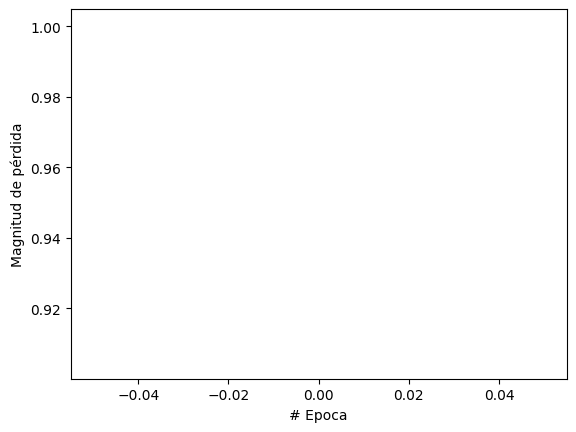

In [31]:
#Ver la funcion de perdida
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(history.history["loss"])

Muestra de predicciones

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


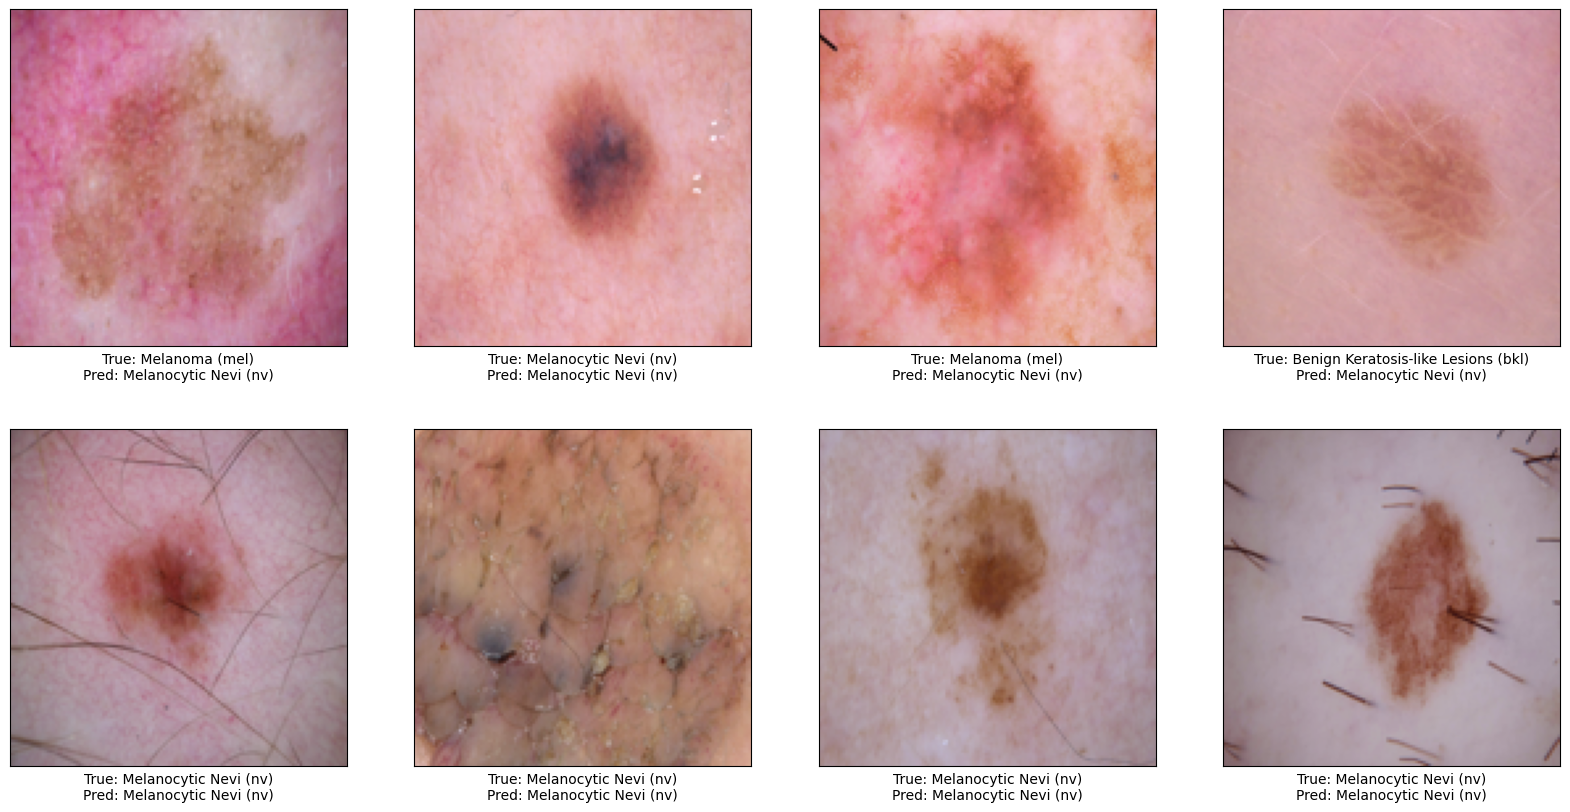

In [32]:
plt.figure(figsize=(20, 10))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_test_image[i])
    true_label = classes[np.argmax(y_encoded_test[i])]
    pred_label = classes[np.argmax(model.predict(X_test_image[i].reshape(1, 128, 128, 3)))]
    plt.xlabel(f'True: {true_label}\nPred: {pred_label}')
plt.show()

El nivel de precision del modelo respecto a las imágenes de prueba lo tomaremos como el porcentaje de aciertos en la clasificación de las imágenes.

In [33]:
model.evaluate(X_test_image, y_encoded_test)


63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.6519 - loss: 0.9015 - precision: 0.7688 - recall: 0.5975


[0.8591572642326355,
 0.6704942584037781,
 0.7808132171630859,
 0.6135796308517456]

# Guardado del modelo en kaggel para posterior uso en pagina web.

In [34]:
# Guardar el modelo

model.save("/kaggle/working/model.h5")




In [35]:
import tensorflow as tf

model = tf.keras.models.load_model("/kaggle/working/model.h5")

In [42]:
model.export("/kaggle/working/saved_model")


Saved artifact at '/kaggle/working/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  132926986184032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132926986506960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132926986517168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132926986516816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132926986575312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132926986578128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132926986576896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132926986582528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132926986578832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132926986732112: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [43]:
converter = tf.lite.TFLiteConverter.from_saved_model(
    "/kaggle/working/saved_model"
)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

tflite_model = converter.convert()

W0000 00:00:1768243882.804898      32 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1768243882.804946      32 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.


In [45]:

with open("/kaggle/working/model.tflite", "wb") as f:
    f.write(tflite_model)


In [46]:
!pip install tflite2onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.2/153.2 kB 5.9 MB/s eta 0:00:00


In [47]:
from tflite2onnx import convert
 
tflite_path = "/kaggle/working/model.tflite"
onnx_path = "/kaggle/working/model.onnx"
 
convert(tflite_path, onnx_path)